<a href="https://colab.research.google.com/github/DenisLVA/sigmoidal_data_science/blob/main/Sobre_o_Matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# importar pacotes
import numpy as np
import matplotlib.pyplot as plt


# Conhecendo o Matplotlib
O Matplotlib é a principal biblioteca para visualização do Python. Construída em cima de arrays do `numpy` e concebida para integrar com as principais ferramentas de Data Science, Matplotlib foi criada em 2002 pelo John Hunter.

John era um neurobiologista que analisava sinais de eletrocorticografia, juntamente com um time de pesquisadores. Como eles usavam um software proprietário e tinham apenas uma licença, o pesquisador criou o matplotlib para subir essa necessidade original, inspirando-se na interface scriptada que o Matlab proporcionava.



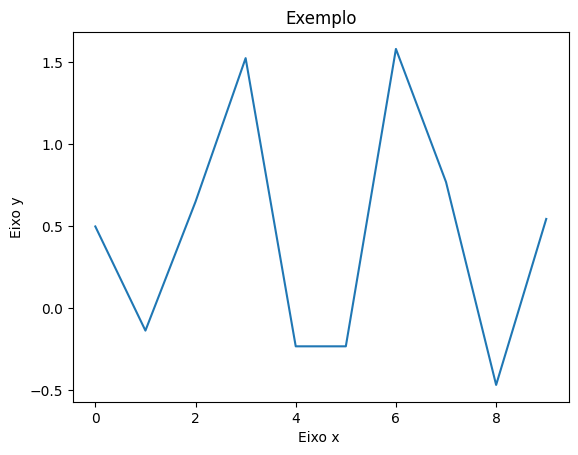

In [3]:
# gerar valores demonstrativos
np.random.seed(42)
x =  np.arange(10)
y = np.random.normal(size=10)

# plotar os valores
plt.plot(x, y)
plt.title("Exemplo")
plt.xlabel("Eixo x ")
plt.ylabel("Eixo y")

plt.show()

Para você, usuário, conseguir se comunicar com essas duas camadas, e manipular as `Figures`, existe uma terceira camada, a camada ***scripting***. Ela abstrai em um nível mais alto todo contato com o Matplotlib, e permite que de maneira simples e direta possamos criar nossos *plots*.

<center><img src="https://raw.githubusercontent.com/carlosfab/curso_data_science_na_pratica/master/modulo_03/matplotlib_arquitetura.jpg" width="400px"></center>

Quero pedir a você para [ler este artigo](https://realpython.com/python-matplotlib-guide/) do *blog* ***Real Python***. É um dos melhores aritogs sobre matplotlib que já tive contato, e vai explicar vários conceitos da ferramenta. Você não precisa saber os detalhes da arquitetura do `matplotlib`, mas precisa ter uma ideia geral sobre seu funcionamento. Caso queira se aprofundar mais ainda, recomendo o livro [*Mastering matplotlib*](https://learning.oreilly.com/library/view/mastering-matplotlib/9781783987542/).

## Conhecendo mais intimamente o Matplotlib

Plotar um gráfico é muito simples e direto. Algo como `plt.plot(x, y)` vai te dar prontamente um gráfico.

No entanto, essa abstração esconde um segredo importante: a hierarquia de 3 objetos que estão por trás de cada *plot*. Vou usar as imagens do artigo [*Python Plotting With Matplotlib*](https://realpython.com/python-matplotlib-guide/) para facilitar o entendimento desse conceito.

<center><img src="https://raw.githubusercontent.com/carlosfab/curso_data_science_na_pratica/master/modulo_03/fig_map.bc8c7cabd823.png" height="300px"></center>

O objeto mais "exterior" a cada plot é o objeto do tipo `Figure`. Dentro de uma `Figure` existe um objeto do tipo `Axes`. Dentro de cada `Axes` ficam os objetos menores, como legendas, títulos, textos e *tick marks*.

Como disse Brad Solomon no artigo, a principal confusão das pessoas é não entenderem que um *plot* (ou gráfico) individual está contido dentro de um objeto `Axes`. Uma `Figure` não é o *plot* em si, ela pode conter um ou mais *plots* (e cada *plot* é um `Axes`).

Como eu disse, cada `Axes` é composto de objetos menores que compõe o *plot* propriamente dito. A grande maioria das pessoas (incluindo eu mesmo) conhece apenas or principais, como título, eixos, labels e legenda. No entanto, para você ver a anatomia completa dentro de um `Axes`, pode usar o código abaixo, disponibilizado na [documentação oficial do `matplotlib`](https://matplotlib.org/examples/showcase/anatomy.html).

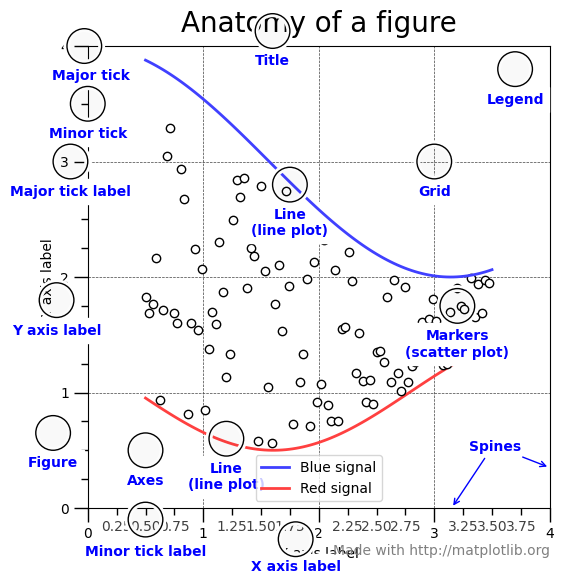

In [4]:
#@title
# This figure shows the name of several matplotlib elements composing a figure

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, FuncFormatter


np.random.seed(19680801)

X = np.linspace(0.5, 3.5, 100)
Y1 = 3+np.cos(X)
Y2 = 1+np.cos(1+X/0.75)/2
Y3 = np.random.uniform(Y1, Y2, len(X))

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1, aspect=1)


def minor_tick(x, pos):
    if not x % 1.0:
        return ""
    return "%.2f" % x

ax.xaxis.set_major_locator(MultipleLocator(1.000))
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_major_locator(MultipleLocator(1.000))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.xaxis.set_minor_formatter(FuncFormatter(minor_tick))

ax.set_xlim(0, 4)
ax.set_ylim(0, 4)

ax.tick_params(which='major', width=1.0)
ax.tick_params(which='major', length=10)
ax.tick_params(which='minor', width=1.0, labelsize=10)
ax.tick_params(which='minor', length=5, labelsize=10, labelcolor='0.25')

ax.grid(linestyle="--", linewidth=0.5, color='.25', zorder=-10)

ax.plot(X, Y1, c=(0.25, 0.25, 1.00), lw=2, label="Blue signal", zorder=10)
ax.plot(X, Y2, c=(1.00, 0.25, 0.25), lw=2, label="Red signal")
ax.plot(X, Y3, linewidth=0,
        marker='o', markerfacecolor='w', markeredgecolor='k')

ax.set_title("Anatomy of a figure", fontsize=20, verticalalignment='bottom')
ax.set_xlabel("X axis label")
ax.set_ylabel("Y axis label")

ax.legend()


def circle(x, y, radius=0.15):
    from matplotlib.patches import Circle
    from matplotlib.patheffects import withStroke
    circle = Circle((x, y), radius, clip_on=False, zorder=10, linewidth=1,
                    edgecolor='black', facecolor=(0, 0, 0, .0125),
                    path_effects=[withStroke(linewidth=5, foreground='w')])
    ax.add_artist(circle)


def text(x, y, text):
    ax.text(x, y, text, backgroundcolor="white",
            ha='center', va='top', weight='bold', color='blue')


# Minor tick
circle(0.50, -0.10)
text(0.50, -0.32, "Minor tick label")

# Major tick
circle(-0.03, 4.00)
text(0.03, 3.80, "Major tick")

# Minor tick
circle(0.00, 3.50)
text(0.00, 3.30, "Minor tick")

# Major tick label
circle(-0.15, 3.00)
text(-0.15, 2.80, "Major tick label")

# X Label
circle(1.80, -0.27)
text(1.80, -0.45, "X axis label")

# Y Label
circle(-0.27, 1.80)
text(-0.27, 1.6, "Y axis label")

# Title
circle(1.60, 4.13)
text(1.60, 3.93, "Title")

# Blue plot
circle(1.75, 2.80)
text(1.75, 2.60, "Line\n(line plot)")

# Red plot
circle(1.20, 0.60)
text(1.20, 0.40, "Line\n(line plot)")

# Scatter plot
circle(3.20, 1.75)
text(3.20, 1.55, "Markers\n(scatter plot)")

# Grid
circle(3.00, 3.00)
text(3.00, 2.80, "Grid")

# Legend
circle(3.70, 3.80)
text(3.70, 3.60, "Legend")

# Axes
circle(0.5, 0.5)
text(0.5, 0.3, "Axes")

# Figure
circle(-0.3, 0.65)
text(-0.3, 0.45, "Figure")

color = 'blue'
ax.annotate('Spines', xy=(4.0, 0.35), xycoords='data',
            xytext=(3.3, 0.5), textcoords='data',
            weight='bold', color=color,
            arrowprops=dict(arrowstyle='->',
                            connectionstyle="arc3",
                            color=color))

ax.annotate('', xy=(3.15, 0.0), xycoords='data',
            xytext=(3.45, 0.45), textcoords='data',
            weight='bold', color=color,
            arrowprops=dict(arrowstyle='->',
                            connectionstyle="arc3",
                            color=color))

ax.text(4.0, -0.4, "Made with http://matplotlib.org",
        fontsize=10, ha="right", color='.5')

plt.show()

De acordo com a documentação oficial do Matplotlib, a biblioteca plota seus dados em objetos do tipo Figure (janelas, Jupyter widgets, entre outros), e esses objetos podem conter um ou mais objetos do tipo Axes (uma área onde pontos podem ser especificados em termos de coordenadas x-y, coordenadas polares, x-y-z, entre outras).

Nessa abordagem orientada a objeto, mais customizações e tipos de gráficos são possíveis.

O estilo "orientado a objeto" cria explicitamente dois objetos, Figure e Axes, e chamada os métodos em cima deles.

A maneira mais simples de criar uma figura com um axes é usando o pyplot.subplots, ou abreviadamente, plt.subplots.

Então, você pode usar o método Axes.plot para desenhar dados em cima de algum axes.

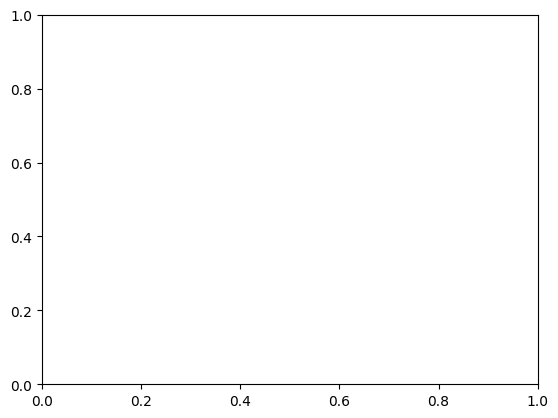

In [5]:
fig,  ax = plt.subplots()

O que fizemos acima foi criar uma Figura que irá conter todos os *plots* (`Axes`). Neste caso, como não especificamos nada, foi criado apenas 1 `Figure` e 1 `Axes` (*plot*).

A partir disso, a manipulação e customização passa a ser diretamente na variável `ax`, chamando seus métodos.

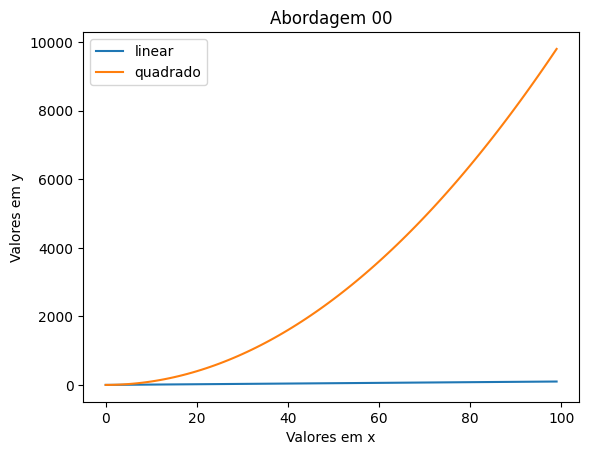

In [10]:
x = np.arange(0, 100)

# plotar os valores
fig, ax = plt.subplots()
ax.plot(x, x, label="linear")
ax.plot(x, x**2, label="quadrado")
ax.set_title("Abordagem 00")
ax.set_ylabel("Valores em y")
ax.set_xlabel("Valores em x")
ax.legend()

# fig.show()
fig.show()

Pronto! Temos o mesmo gráfico, porém ganhamos um controle bem maior de manipulação sobre ele. Veja o exemplo abaixo, onde eu crio 2 objetos do tipo `Axes` para plotar 2 gráficos diferentes em 1 única `Figure`.

In [ ]:
# plotar os 2 gráficos
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8,3))

# gráfico 1
ax[0].plot(x, x)
ax[0].set_title("Linear")
ax[0].set_ylabel("Valores em x")
ax[0].set_xlabel("Valores em y")

# gráfico 2
ax[1].plot(x, x**2)
ax[1].set_title("Quadrado")
ax[1].set_ylabel("Valores em x")
ax[1].set_xlabel("Valores em y")

fig.tight_layout();

## Abordagem Interface Pyplot

Se acima nós precisamos criar explicitamente figuras e *axes*, há uma outra abordagem que delega toda a responsabilidade de se criar e gerenciar as mesmas.

Para isso, você vai usar as funções do `pyplot` para plotar. Veja como usar esse *pyplot-style*.

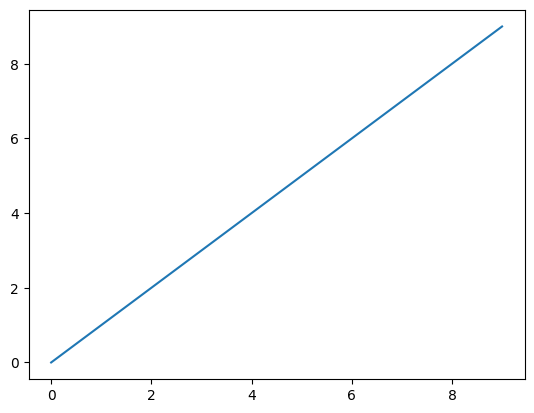

In [11]:
x = np.arange(10)

plt.plot(x, x)

Se eu quiser adicionar um título ao gráfico, posso fazer diretamente, seguindo a mesma abordagem:

Text(0, 0.5, 'Eixo y')

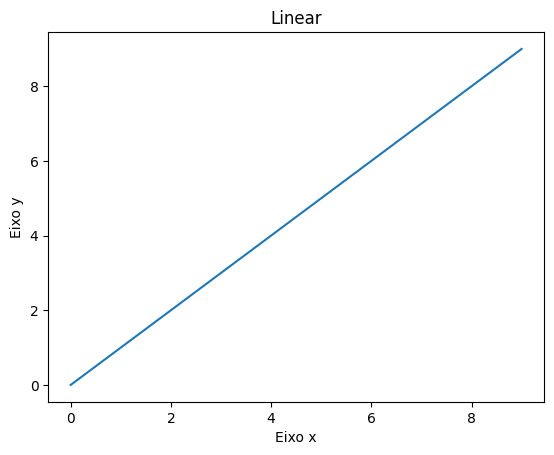

In [13]:
plt.plot(x, x)
plt.title("Linear")
plt.xlabel("Eixo x")
plt.ylabel("Eixo y")


De maneira similar, se eu quiser ir acrescentando objetos ao Axes, eu vou apenas adicionando novas funções sequencialmente:

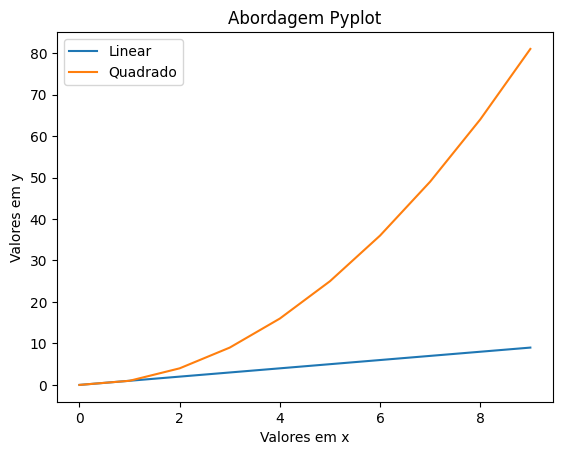

In [14]:
plt.plot(x, x, label="Linear")
plt.plot(x, x**2, label="Quadrado")
plt.title("Abordagem Pyplot")
plt.ylabel("Valores em y")
plt.xlabel("Valores em x")
plt.legend()
plt.show()

Isso ocorre porque quando eu executo qualquer função de pyplot, como plt.plot() ou plt.title(), ocorre uma das seguintes coisas:

Implicitamente usam Figure e Axes atuais (caso já existam)
Cria novos objetos Figure e Axes (caso não existam ainda)
Brad Solomon destaca um trecho da documentação oficial do matplotlib que diz o seguinte:

Com o pyplot, funções simples são usadas para adicionar elementos de plot (linhas, imagens, textos, entre outras) ao Axes atual, pertencente à Figure atual.

Qual abordagem você deve usar?
A documentação oficial considera as duas abordagens igualmente poderosas. Você deve se sentir livre para adotar qualquer uma, porém deve buscar não ficar misturando as abordagens.

Sugere ainda a documentação, que o uso do pyplot pode ser restrito aos plot interativos (como o caso do Jupyter notebook) e a abordagem Orientada a Objeto como preferencial para plots não-interativos (funcões e scripts utilizados em um projeto maior, por exemplo).